#Yolov8 Plate Detection


###Enviroment


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
%cd /content/drive/MyDrive/Number Plate Regocnition App/Plate Reading

/content/drive/MyDrive/Number Plate Regocnition App/Plate Reading


In [18]:
%pip install ultralytics
import ultralytics
ultralytics.checks()


Ultralytics 8.3.74 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 33.3/112.6 GB disk)


##Test


In [19]:
!yolo detect predict model=yolov8l.pt source="'https://ultralytics.com/images/bus.jpg'"

100% 83.7M/83.7M [00:00<00:00, 122MB/s]
Ultralytics 8.3.74 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8l summary (fused): 268 layers, 43,668,288 parameters, 0 gradients, 165.2 GFLOPs

100% 134k/134k [00:00<00:00, 8.80MB/s]
image 1/1 /content/drive/MyDrive/Number Plate Regocnition App/Plate Reading/bus.jpg: 640x480 5 persons, 1 bicycle, 1 bus, 59.4ms
Speed: 2.6ms preprocess, 59.4ms inference, 140.7ms postprocess per image at shape (1, 3, 640, 480)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


In [20]:
import cv2
import imutils
from google.colab.patches import cv2_imshow

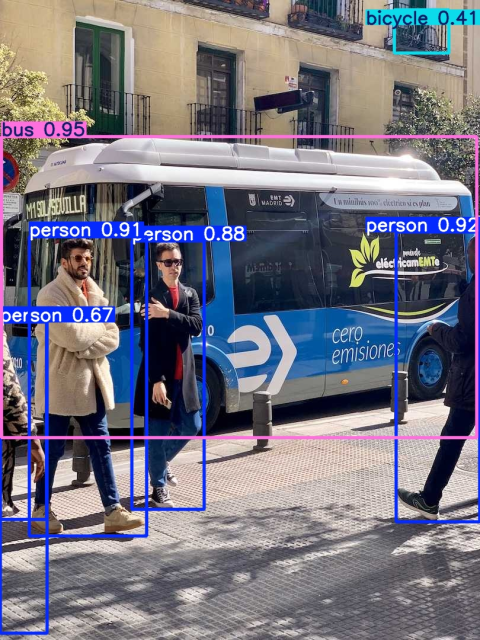

In [21]:
img=cv2.imread('/content/drive/MyDrive/Number Plate Regocnition App/Plate Detection/runs/detect/predict/bus.jpg')
img=imutils.resize(img,width=480)
cv2_imshow(img)

###Python Implemantion


In [22]:
import cv2
import imutils
from ultralytics import YOLO
from google.colab.patches import cv2_imshow


0: 640x480 5 persons, 1 bicycle, 1 bus, 48.7ms
Speed: 2.2ms preprocess, 48.7ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 480)


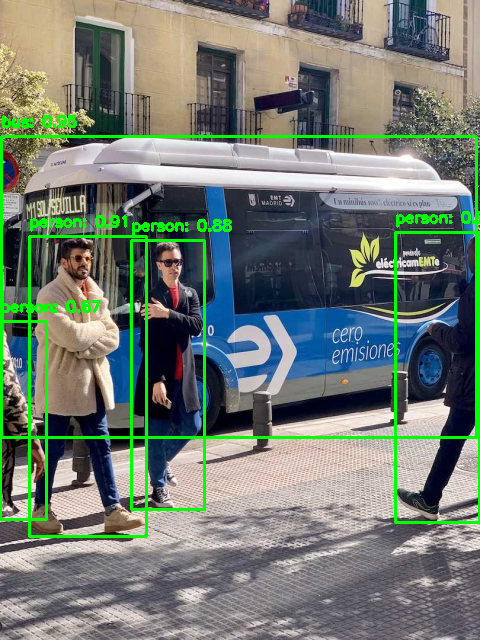

In [23]:
img_path="bus.jpg"
model_path="yolov8l.pt"
font=cv2.FONT_HERSHEY_SIMPLEX

model=YOLO(model_path)
img=cv2.imread(img_path)
img=imutils.resize(img,width=480)
results=model(img)[0]
threshold=0.5

for result in results.boxes.data.tolist():
  x1,y1,x2,y2,score,class_id=result
  x1,y1,x2,y2,class_id=int(x1),int(y1),int(x2),int(y2),int(class_id)
  if score>threshold:
    cv2.rectangle(img,(x1,y1),(x2,y2),(0,255,0),2)

    class_name=results.names[class_id]
    text=f"{class_name}: {score:.2f}"

    cv2.putText(img,text,(x1,y1-10),font,0.5,(0,255,0),2)

cv2_imshow(img)



##Dataset

In [ ]:
!unzip Data/character_dataset.zip -d ./Data

###Train

In [28]:
!yolo detect train data=Data/config.yaml model=yolov8n.pt epochs=25 imgsz=320 workers=8 batch=12 device=0 name=yolov8n-plate-reading

Ultralytics 8.3.74 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=Data/config.yaml, epochs=25, time=None, patience=100, batch=12, imgsz=320, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=yolov8n-plate-reading2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_b

###Prediction


In [30]:
!yolo detect predict model=runs/detect/yolov8n-plate-reading2/weights/best.pt source=Data/character_dataset/images/test save=True

Ultralytics 8.3.74 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 168 layers, 3,011,693 parameters, 0 gradients, 8.1 GFLOPs

image 1/500 /content/drive/MyDrive/Number Plate Regocnition App/Plate Reading/Data/character_dataset/images/test/1001.jpg: 96x320 1 5, 1 7, 1 D, 1 H, 1 M, 1 R, 1 U, 1 V, 33.1ms
image 2/500 /content/drive/MyDrive/Number Plate Regocnition App/Plate Reading/Data/character_dataset/images/test/1006.jpg: 96x320 1 B, 1 G, 1 K, 1 L, 1 N, 1 R, 1 U, 1 V, 6.7ms
image 3/500 /content/drive/MyDrive/Number Plate Regocnition App/Plate Reading/Data/character_dataset/images/test/1058.jpg: 96x320 2 0s, 1 1, 1 M, 1 R, 2 Xs, 6.3ms
image 4/500 /content/drive/MyDrive/Number Plate Regocnition App/Plate Reading/Data/character_dataset/images/test/1060.jpg: 288x320 1 8, 2 9s, 2 Fs, 1 R, 1 T, 1 X, 32.8ms
image 5/500 /content/drive/MyDrive/Number Plate Regocnition App/Plate Reading/Data/character_dataset/images/test/1065.jpg: 96x320 1 5, 1 B, 1 F, 1 G, 